Starting optimization with hyperparameter AND inducing point updates...


ELBO: -154.71:   0%|          | 0/1000 [00:00<?, ?it/s]

ELBO: -164.19: 100%|██████████| 1000/1000 [00:38<00:00, 26.23it/s]



--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Optimized Z ---
[-4.69559607 -3.88834423 -3.42012314 -3.02781432 -2.58795112 -1.81869868
 -0.84390444 -0.24099223  0.1783747   0.27061255  0.60265479  1.32253242
  2.17422688  2.2608307   2.6515889   2.82511318  2.96012029  3.41004051
  3.8970912   4.71626239]
-------------------


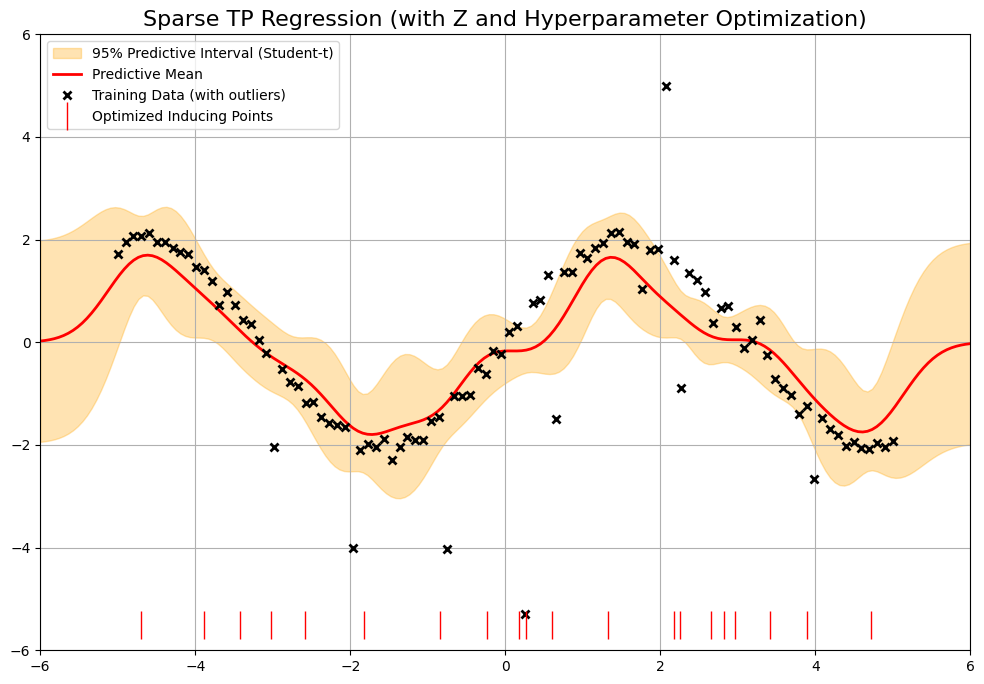

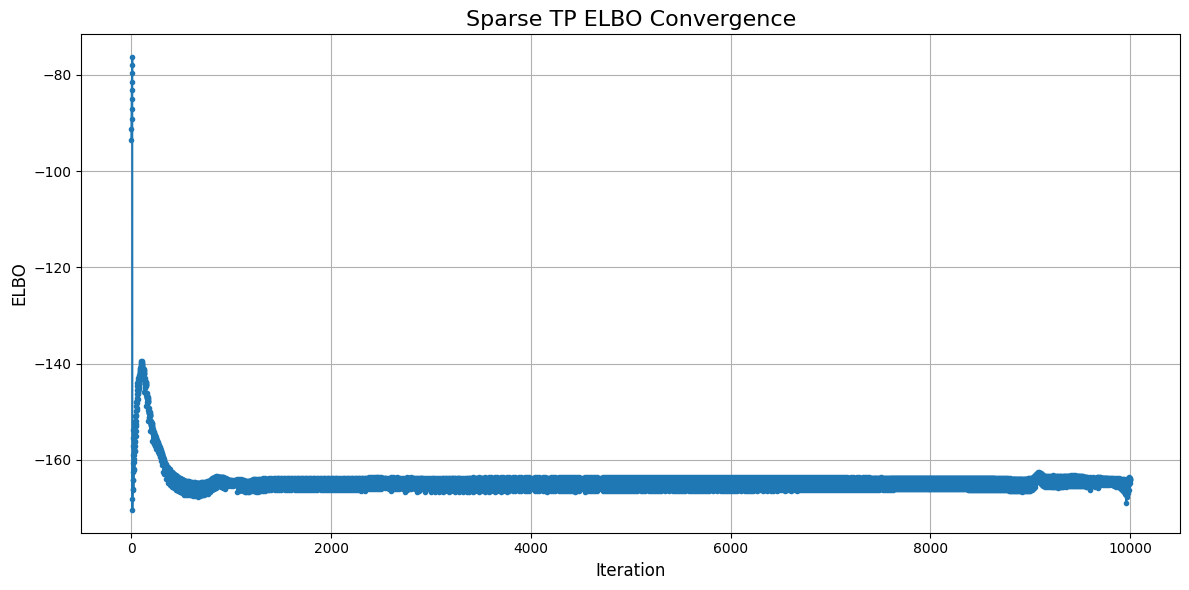

In [15]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class TPRegression(nn.Module):
    """
    Implements the sparse Student-t Process regression model using inducing points.
    This is suitable for larger datasets as it avoids the O(N^3) complexity
    by working with an M x M kernel matrix, where M << N.
    """
    def __init__(self, X, y, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # --- Hyperparameters and Inducing Points as nn.Parameter ---
        # Z is now a parameter to be optimized
        self.Z = nn.Parameter(Z_initial.clone())

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # Variational Parameters (not optimized by gradient descent, so not nn.Parameter)
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self, E_q_f, Var_q_f):
        """CAVI update for q(lambda_i)."""
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        self.alpha_lambda = nu_e / 2.0 + 0.5
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, E_quad_form_u):
        """CAVI update for q(r)."""
        _, _, _, nu_f, _ = self._get_hyperparams()
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()

    # def _update_q_u(self, Kzz, Lzz, Kxz):
    #     """CAVI update for q(u)."""
    #     _, _, sigma_sq, _, _ = self._get_hyperparams()
    #     E_r = self.alpha_r / self.beta_r
    #     E_lambda = self.alpha_lambda / self.beta_lambda

    #     Psi = Kxz.T @ (E_lambda * Kxz) / sigma_sq
    #     B = E_r * Kzz + Psi
    #     L_B = torch.linalg.cholesky(B)

    #     Kzz_invB_Kzz = torch.cholesky_solve(Kzz, L_B)
    #     S_u = Kzz @ Kzz_invB_Kzz
    #     S_u = 0.5 * (S_u + S_u.T) # Ensure symmetry
    #     self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)

    #     temp_vec = (Kxz.T * E_lambda.T) @ self.y / sigma_sq
    #     m_u_unscaled = torch.cholesky_solve(temp_vec, L_B)
    #     self.m_u = Kzz @ m_u_unscaled

    def _update_q_u(self, Kzz, Lzz, Kxz):
        """
        CORRECTED CAVI update for global parameter q(u).
        This version uses the correct precision matrix formulation.
        """
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        # 1. Get Kzz_inv efficiently from its Cholesky factor Lzz
        Kzz_inv = torch.cholesky_inverse(Lzz)

        # 2. Calculate the precision matrix (inverse covariance) of q(u)
        # S_u_inv = E[r] * Kzz_inv + (1/sigma^2) * Kxz^T * E[lambda] * Kxz
        Psi_matrix = (Kxz.T * E_lambda.T) @ Kxz
        S_u_inv = E_r * Kzz_inv + Psi_matrix / sigma_sq
        
        # 3. Calculate the covariance S_u by inverting the precision matrix
        # We do this via Cholesky for numerical stability
        L_S_inv = torch.linalg.cholesky(S_u_inv)
        S_u = torch.cholesky_inverse(L_S_inv)
        S_u = 0.5 * (S_u + S_u.T) # Ensure symmetry
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)

        # 4. Calculate the mean m_u
        # m_u = S_u @ (1/sigma^2) * Kxz^T * E[lambda] * y
        temp_vec = (E_lambda * self.y).T @ Kxz
        self.m_u = (S_u @ temp_vec.T) / sigma_sq

    def _cavi_step(self, Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter=10, cavi_tol=1e-5):
        """Runs the inner CAVI loop until convergence for fixed hyperparameters."""
        for _ in range(cavi_max_iter):
            m_u_old = self.m_u.clone()

            # Required expectations for updates
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f = Kxz @ Kzz_inv_mu

            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

            A = torch.linalg.solve(Kzz, Kxz.T).T
            var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
            Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

            S_u = self.L_u @ self.L_u.T
            Kzz_inv_Su = torch.cholesky_solve(S_u, Lzz)
            trace_term = torch.trace(Kzz_inv_Su)
            quad_form_term = self.m_u.T @ Kzz_inv_mu
            E_quad_form_u = trace_term + quad_form_term

            # CAVI updates
            self._update_q_lambda(E_q_f, Var_q_f)
            self._update_q_r(E_quad_form_u)
            self._update_q_u(Kzz, Lzz, Kxz)

            change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self):
        """
        Calculates the Evidence Lower Bound (ELBO).
        This method uses self.Z, self.X, so it's compatible with Z being a parameter.
        It's important that kernel() is called inside, as it will use the current self.Z.
        """
        lengthscale, variance, sigma_sq, nu_f, nu_e = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(self.X, self.Z)
        Kxx_diag = self.kernel(self.X, self.X).diag()

        # --- 1. Expected Log Likelihood ---
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu

        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for u and r ---
        S_u = self.L_u @ self.L_u.T
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - torch.sum(torch.log(torch.diag(self.L_u))) - 0.5 * self.M
        
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_det_Kzz = 2 * torch.sum(torch.log(torch.diag(Lzz)))
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * log_det_Kzz + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u

        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * E_log_lambda + \
                    (self.beta_lambda - nu_e / 2) * E_lambda

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_u_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter_global=50, max_iter_local=1, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Fits the model by jointly optimizing hyperparameters and inducing points (M-step)
        and updating variational parameters (E-step).
        Returns the history of ELBO values.
        """
        elbo_history = [] # ADDED: To store ELBO values

        print("Starting optimization with hyperparameter AND inducing point updates...")
        pbar = tqdm.trange(max_iter_global)
        for i in pbar:
            # --- E-Step: Update variational parameters with fixed hypers/Z ---
            # K matrices are computed once before CAVI, as Z and hypers are fixed during E-step.
            with torch.no_grad():
                Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
                Lzz = torch.linalg.cholesky(Kzz)
                Kxz = self.kernel(self.X, self.Z)
                Kxx_diag = self.kernel(self.X, self.X).diag()
                self._cavi_step(Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter, cavi_tol)

            optimizer = torch.optim.Adam(self.parameters(), lr=lr)
            for j in range(max_iter_local):
                # --- M-Step: Update hyperparameters and Z by maximizing ELBO ---
                optimizer.zero_grad()
                # ELBO is calculated with current parameters (including Z) to get gradients
                neg_elbo = -self.calculate_elbo()
                neg_elbo.backward()
                optimizer.step()

                # ADDED: Store ELBO for plotting
                current_elbo = -neg_elbo.item()
                elbo_history.append(current_elbo)
                pbar.set_description(f"ELBO: {current_elbo:.2f}")
        
        return elbo_history # ADDED: Return the history

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            # We use .detach() on Z as we don't want prediction to be part of the computation graph.
            Z_final = self.Z
            K_star_z = self.kernel(X_test, Z_final)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kzz = self.kernel(Z_final, Z_final) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)

            # Predictive Mean
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            pred_mean = K_star_z @ Kzz_inv_mu

            # Predictive Variance
            S_u = self.L_u @ self.L_u.T
            A_star = torch.linalg.solve(Kzz, K_star_z.T).T
            var_from_q_u = torch.sum((A_star @ self.L_u)**2, dim=1)

            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

            pred_var = var_from_prior + var_from_q_u
            
            # Predictive degrees of freedom
            pred_nu = 2 * self.alpha_r

            return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()
        


if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model with INITIAL inducing points
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model and get ELBO history
    # MODIFIED: Capture the returned elbo_history
    elbo_history = model.fit(max_iter_global=1000, max_iter_local=10, lr=0.01, cavi_max_iter=1)

    # Print final Z locations
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    # Plot final optimized inducing points
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, label='Optimized Inducing Points')

    plt.title('Sparse TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. ADDED: Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='.', linestyle='-')
    plt.title('Sparse TP ELBO Convergence', fontsize=16)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()


In [2]:
import torch

# A placeholder for a kernel function (e.g., RBF)
def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class TPRegressionCAVI:
    """
    PyTorch implementation of CAVI for Student-t Process Regression
    with a Student-t Likelihood, based on the provided document.
    """
    def __init__(self, X, y, M=20, nu_f=5.0, nu_epsilon=5.0, sigma_sq=1.0):
        """
        Initializes the model and variational parameters. [cite: 133]

        Args:
            X (torch.Tensor): Training inputs (N x D).
            y (torch.Tensor): Training outputs (N x 1).
            M (int): Number of inducing points.
            nu_f (float): Degrees of freedom for the TP prior. [cite: 13]
            nu_epsilon (float): Degrees of freedom for the likelihood. [cite: 19]
            sigma_sq (float): Scale parameter for the likelihood noise. [cite: 19]
        """
        self.X = X
        self.y = y.squeeze()
        self.N, self.D = X.shape
        self.M = M

        # Initialize hyperparameters [cite: 133]
        self.nu_f = torch.tensor(nu_f)
        self.nu_epsilon = torch.tensor(nu_epsilon)
        self.sigma_sq = torch.tensor(sigma_sq)
        self.kernel = rbf_kernel

        # Initialize inducing points Z by selecting M random points from X
        indices = torch.randperm(self.N)[:self.M]
        self.Z = self.X[indices].clone()

        # Pre-compute kernel matrices
        self.K_ZZ = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        self.K_ZZ_inv = torch.inverse(self.K_ZZ)
        self.K_XZ = self.kernel(self.X, self.Z)
        
        # --- Initialize Variational Parameters --- [cite: 133]
        # q(u) = N(m_u, S_u)
        self.m_u = torch.zeros(self.M, 1) # [cite: 47]
        self.S_u = torch.eye(self.M)       # [cite: 47]

        # q(r) = Gamma(alpha_r, beta_r)
        self.alpha_r = torch.tensor(1.0) # [cite: 49]
        self.beta_r = torch.tensor(1.0)  # [cite: 49]

        # q(lambda_i) = Gamma(alpha_lambda_i, beta_lambda_i)
        self.alpha_lambda = torch.ones(self.N) # [cite: 51]
        self.beta_lambda = torch.ones(self.N)  # [cite: 51]

    def _update_q_lambda(self):
        """
        Updates the variational parameters for q(lambda_i) for all i=1..N.
        This corresponds to lines 5-8 in Algorithm 1. [cite: 137, 143]
        """
        # 1. Compute expected squared error E_q[(y_i - f_i)^2] [cite: 141]
        # E_q[(y_i - f_i)^2] = (y_i - E[f_i])^2 + Var(f_i) [cite: 112]
        
        # Calculate E[f_i] = k_i,Z * K_ZZ^-1 * m_u [cite: 114]
        K_ZZ_inv_m_u = torch.linalg.solve(self.K_ZZ, self.m_u)
        expected_f_mean = self.K_XZ @ K_ZZ_inv_m_u

        # Calculate Var(f_i) [cite: 116, 118]
        # We need E[r^-1] = beta_r / (alpha_r - 1) for alpha_r > 1 [cite: 119]
        if self.alpha_r > 1:
            expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else:
            expected_r_inv = self.beta_r # Fallback for stability at initialization
        
        k_ii = torch.diag(self.kernel(self.X, self.X))
        K_XZ_K_ZZ_inv = self.K_XZ @ self.K_ZZ_inv
        
        var_f_term1 = expected_r_inv * (k_ii - (K_XZ_K_ZZ_inv * self.K_XZ).sum(dim=1))
        var_f_term2 = (K_XZ_K_ZZ_inv @ self.S_u * K_XZ_K_ZZ_inv).sum(dim=1)
        var_f = var_f_term1 + var_f_term2
        
        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f

        # 2. Update alpha_lambda and beta_lambda using Eq. (1) and (2) [cite: 62, 64]
        self.alpha_lambda = self.nu_epsilon / 2.0 + 0.5
        self.beta_lambda = self.nu_epsilon / 2.0 + (0.5 / self.sigma_sq) * expected_sq_error

    def _update_q_r(self):
        """
        Updates the variational parameters for the global precision q(r).
        This corresponds to lines 10-12 in Algorithm 1. [cite: 146, 150]
        """
        # 1. Compute E_q(u)[u^T * K_ZZ^-1 * u] [cite: 148]
        # Using formula: Tr(A*Sigma) + mu^T*A*mu [cite: 122]
        trace_term = torch.trace(self.K_ZZ_inv @ self.S_u)
        mean_term = self.m_u.T @ self.K_ZZ_inv @ self.m_u
        expected_u_quadratic_form = trace_term + mean_term

        # 2. Update alpha_r and beta_r using Eq. (3) and (4) [cite: 67, 68]
        self.alpha_r = self.nu_f / 2.0 + self.M / 2.0
        self.beta_r = self.nu_f / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

    def _update_q_u(self):
        """
        Updates the variational parameters for q(u).
        This corresponds to lines 15-17 in Algorithm 1. [cite: 159, 162]
        """
        # 1. Compute required expectations E[r] and E[lambda_i] [cite: 160]
        # E[X] = alpha / beta for X ~ Gamma(alpha, beta) [cite: 126]
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = self.alpha_lambda / self.beta_lambda
        
        # 2. Update S_u and m_u [cite: 106]
        K_ZZ_inv_T = self.K_ZZ_inv.T
        
        # Compute the precision matrix (S_u*)^-1
        # First part of the sum for the precision matrix
        precision_u_prior = expected_r * self.K_ZZ_inv
        
        # Second part of the sum (from the likelihood)
        expected_prec_lambda = self.sigma_sq * expected_lambda
        K_ZX = self.K_XZ.T
        # Efficiently compute sum over N of k_Z,i * k_i,Z
        A = K_ZX * expected_prec_lambda # Element-wise mult broadcasts lambda
        B = A @ self.K_XZ
        
        precision_u_lik = K_ZZ_inv_T @ B @ self.K_ZZ_inv
        
        precision_u = precision_u_prior + precision_u_lik
        
        # Updated S_u is the inverse of the precision matrix
        self.S_u = torch.inverse(precision_u + torch.eye(self.M) * 1e-6)

        # Compute the mean-related term `b` to find the new m_u
        b = K_ZZ_inv_T @ (K_ZX @ (expected_prec_lambda * self.y))
        self.m_u = (self.S_u @ b).unsqueeze(1)


    def fit(self, num_iterations=100, tol=1e-5):
        """
        Runs the CAVI algorithm until convergence. [cite: 132, 164]
        """
        print("Starting CAVI optimization...")
        for i in range(num_iterations):
            m_u_old = self.m_u.clone()
            
            # --- Perform CAVI updates in sequence ---
            # 1. Update local likelihood precisions q(lambda_i)
            self._update_q_lambda()
            
            # 2. Update global prior precision q(r)
            self._update_q_r()
            
            # 3. Update inducing point distribution q(u)
            self._update_q_u()
            
            # Check for convergence
            change = torch.norm(self.m_u - m_u_old) / torch.norm(m_u_old)
            print(f"Iteration {i+1}/{num_iterations}, Change in m_u: {change.item():.6f}")
            if change < tol:
                print(f"Convergence reached after {i+1} iterations.")
                break
        print("Optimization finished.")

# Example usage (requires data)
if __name__ == '__main__':
    # --- Create synthetic data for demonstration ---
    N_train = 100
    D_dim = 1
    X_train = torch.linspace(-5, 5, N_train).unsqueeze(1)
    # True function with some noise
    y_true = torch.sin(X_train) + torch.randn(N_train, 1) * 0.2
    # Add some outliers
    outlier_indices = [10, 20, 80]
    y_train = y_true.clone()
    y_train[outlier_indices] += torch.tensor([5.0, -4.0, 6.0]).unsqueeze(1)

    # --- Initialize and run the model ---
    model = TPRegressionCAVI(X_train, y_train, M=20, nu_f=5.0, nu_epsilon=5.0)
    model.fit(num_iterations=500)

    # After fitting, model.m_u, model.S_u, etc., contain the learned parameters.
    # A predict() function would use these to compute the predictive distribution
    # on new test points, as described in Section 7. [cite: 167]

Starting CAVI optimization...
Iteration 1/500, Change in m_u: inf
Iteration 2/500, Change in m_u: 0.799573
Iteration 3/500, Change in m_u: 3.801648
Iteration 4/500, Change in m_u: 1.465262
Iteration 5/500, Change in m_u: 0.826720
Iteration 6/500, Change in m_u: 0.600690
Iteration 7/500, Change in m_u: 5.518776
Iteration 8/500, Change in m_u: 0.862855
Iteration 9/500, Change in m_u: 0.564867
Iteration 10/500, Change in m_u: 0.666476
Iteration 11/500, Change in m_u: 0.628401
Iteration 12/500, Change in m_u: 0.218767
Iteration 13/500, Change in m_u: 0.166310
Iteration 14/500, Change in m_u: 0.190701
Iteration 15/500, Change in m_u: 0.130451
Iteration 16/500, Change in m_u: 0.121979
Iteration 17/500, Change in m_u: 0.365321
Iteration 18/500, Change in m_u: 0.357471
Iteration 19/500, Change in m_u: 0.580860
Iteration 20/500, Change in m_u: 0.652232
Iteration 21/500, Change in m_u: 0.362624
Iteration 22/500, Change in m_u: 1.467717
Iteration 23/500, Change in m_u: 1.037788
Iteration 24/500, 

In [3]:
import torch
import torch.optim as optim

# A placeholder for a kernel function (e.g., RBF)
def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class TPRegressionVariationalEM:
    """
    Implementation of Variational EM for Student-t Process Regression.
    - E-Step: CAVI updates for variational parameters.
    - M-Step: Gradient-based optimization of model hyperparameters.
    """
    def __init__(self, X, y, M=20):
        self.X = X
        self.y = y.squeeze()
        self.N, self.D = X.shape
        self.M = M

        # --- Initialize Hyperparameters to be Optimized (M-step) ---
        # These are now learnable parameters.
        self.log_nu_f = torch.nn.Parameter(torch.log(torch.tensor(5.0)))
        self.log_nu_epsilon = torch.nn.Parameter(torch.log(torch.tensor(5.0)))
        self.log_sigma_sq = torch.nn.Parameter(torch.log(torch.tensor(1.0)))
        self.log_kernel_lengthscale = torch.nn.Parameter(torch.tensor(0.0))
        self.log_kernel_variance = torch.nn.Parameter(torch.tensor(0.0))

        # --- Initialize Variational Parameters (E-step) ---
        indices = torch.randperm(self.N)[:self.M]
        self.Z = self.X[indices].clone()

        self.m_u = torch.zeros(self.M, 1)
        self.S_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        self.alpha_lambda = torch.ones(self.N)
        self.beta_lambda = torch.ones(self.N)
        
        # Optimizer for the M-step
        self.optimizer = optim.Adam(
            [self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
             self.log_kernel_lengthscale, self.log_kernel_variance],
            lr=0.01
        )

    def _get_hyperparams(self):
        """Returns the exponentiated (positive) hyperparameters."""
        return {
            "nu_f": torch.exp(self.log_nu_f),
            "nu_epsilon": torch.exp(self.log_nu_epsilon),
            "sigma_sq": torch.exp(self.log_sigma_sq),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }
        
    def _e_step(self, cavi_iterations=10):
        """Performs the CAVI updates for the variational parameters (E-Step)."""
        with torch.no_grad(): # No gradients needed for the E-step updates
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
            K_ZZ_inv = torch.inverse(K_ZZ)
            K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
            
            for _ in range(cavi_iterations):
                # Update q(lambda)
                K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
                expected_f_mean = K_XZ @ K_ZZ_inv_m_u
                if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
                else: expected_r_inv = self.beta_r
                k_ii = torch.diag(rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']))
                K_XZ_K_ZZ_inv = K_XZ @ K_ZZ_inv
                var_f_term1 = expected_r_inv * (k_ii - (K_XZ_K_ZZ_inv * K_XZ).sum(dim=1))
                var_f_term2 = (K_XZ_K_ZZ_inv @ self.S_u * K_XZ_K_ZZ_inv).sum(dim=1)
                var_f = var_f_term1 + var_f_term2
                expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
                self.alpha_lambda = params['nu_epsilon'] / 2.0 + 0.5
                self.beta_lambda = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error

                # Update q(r)
                trace_term = torch.trace(K_ZZ_inv @ self.S_u)
                mean_term = self.m_u.T @ K_ZZ_inv @ self.m_u
                expected_u_quadratic_form = trace_term + mean_term
                self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
                self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

                # Update q(u)
                expected_r = self.alpha_r / self.beta_r
                expected_lambda = self.alpha_lambda / self.beta_lambda
                precision_u_prior = expected_r * K_ZZ_inv
                K_ZX = K_XZ.T
                A = K_ZX * (params['sigma_sq'] * expected_lambda)
                B = A @ K_XZ
                precision_u_lik = K_ZZ_inv.T @ B @ K_ZZ_inv
                precision_u = precision_u_prior + precision_u_lik
                self.S_u = torch.inverse(precision_u + torch.eye(self.M) * 1e-6)
                b = K_ZZ_inv.T @ (K_ZX @ (params['sigma_sq'] * expected_lambda * self.y))
                self.m_u = (self.S_u @ b).unsqueeze(1)

    def _calculate_elbo(self):
        """
        Calculates the Evidence Lower Bound (ELBO)[cite: 194].
        This is required for the M-step.
        """
        params = self._get_hyperparams()
        
        # Kernel matrices needed for ELBO
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
        K_ZZ_inv = torch.inverse(K_ZZ)
        K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
        k_ii = torch.diag(rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']))

        # 1. Expected Log-Likelihood term: E[log p(y|f, {lambda_i})] [cite: 190]
        # E[log N(y_i|f_i, (sigma^2*lambda_i)^-1)]
        expected_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
        expected_lambda = self.alpha_lambda / self.beta_lambda
        
        K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
        expected_f_mean = K_XZ @ K_ZZ_inv_m_u
        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        K_XZ_K_ZZ_inv = K_XZ @ K_ZZ_inv
        var_f_term1 = expected_r_inv * (k_ii - (K_XZ_K_ZZ_inv * K_XZ).sum(dim=1))
        var_f_term2 = (K_XZ_K_ZZ_inv @ self.S_u * K_XZ_K_ZZ_inv).sum(dim=1)
        var_f = var_f_term1 + var_f_term2
        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
        
        expected_log_lik = 0.5 * torch.sum(expected_log_lambda - torch.log(2 * torch.pi * params['sigma_sq']) - expected_lambda / params['sigma_sq'] * expected_sq_error)

        # 2. KL Divergence terms [cite: 191, 192]
        # KL(q(r)||p(r))
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) \
               + p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
        # KL(q(u)||p(u|r)) averaged over q(r)
        # We use E_q[log q(u) - log p(u|r)]
        log_det_S_u = torch.logdet(self.S_u)
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        expected_r = self.alpha_r / self.beta_r
        
        kl_u_term1 = 0.5 * (-log_det_S_u - self.M * expected_log_r + torch.logdet(K_ZZ))
        kl_u_term2 = 0.5 * expected_r * (torch.trace(K_ZZ_inv @ self.S_u) + self.m_u.T @ K_ZZ_inv @ self.m_u)
        kl_u = kl_u_term1 + kl_u_term2.squeeze() - 0.5 * self.M
        
        kl_u_r = kl_u + kl_r
        
        # KL(q(lambda_i)||p(lambda_i))
        p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda = torch.sum((self.alpha_lambda - p_alpha_lambda) * torch.digamma(self.alpha_lambda) \
                    - torch.lgamma(self.alpha_lambda) + torch.lgamma(p_alpha_lambda) \
                    + p_alpha_lambda * (torch.log(self.beta_lambda) - torch.log(p_beta_lambda)) \
                    + self.alpha_lambda * (p_beta_lambda - self.beta_lambda) / self.beta_lambda)

        elbo = expected_log_lik - kl_u_r - kl_lambda
        return elbo

    def _m_step(self, iterations=10):
        """Performs the gradient update for the hyperparameters (M-Step)."""
        self.optimizer.zero_grad()

        for _ in range(iterations):
            elbo = self._calculate_elbo()
            loss = -elbo # We maximize ELBO, so we minimize -ELBO
            loss.backward()
            self.optimizer.step()
        return elbo.item()

    def fit(self, em_iterations=50, cavi_per_step=10):
        """
        Runs the full Variational EM algorithm.
        """
        print("Starting Variational EM optimization...")
        for i in range(em_iterations):
            # E-Step: Update variational parameters
            self._e_step(cavi_iterations=cavi_per_step)
            
            # M-Step: Update hyperparameters
            elbo = self._m_step()
            
            print(f"EM Iteration {i+1}/{em_iterations}, ELBO: {elbo:.4f}")
        
        print("\nOptimization finished.")
        final_params = self._get_hyperparams()
        print("Final Hyperparameters:")
        for name, val in final_params.items():
            print(f"  {name}: {val.item():.4f}")


if __name__ == '__main__':
    import matplotlib.pyplot as plt

    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0


    model = TPRegressionVariationalEM(X_train, y_train, M=20)
    model.fit(em_iterations=2000, cavi_per_step=5)

Starting Variational EM optimization...
EM Iteration 1/2000, ELBO: nan
EM Iteration 2/2000, ELBO: nan
EM Iteration 3/2000, ELBO: nan
EM Iteration 4/2000, ELBO: nan
EM Iteration 5/2000, ELBO: nan
EM Iteration 6/2000, ELBO: nan
EM Iteration 7/2000, ELBO: nan
EM Iteration 8/2000, ELBO: nan
EM Iteration 9/2000, ELBO: nan
EM Iteration 10/2000, ELBO: nan
EM Iteration 11/2000, ELBO: nan
EM Iteration 12/2000, ELBO: nan
EM Iteration 13/2000, ELBO: nan
EM Iteration 14/2000, ELBO: nan
EM Iteration 15/2000, ELBO: nan
EM Iteration 16/2000, ELBO: nan
EM Iteration 17/2000, ELBO: nan
EM Iteration 18/2000, ELBO: nan
EM Iteration 19/2000, ELBO: nan
EM Iteration 20/2000, ELBO: nan
EM Iteration 21/2000, ELBO: nan
EM Iteration 22/2000, ELBO: nan
EM Iteration 23/2000, ELBO: nan
EM Iteration 24/2000, ELBO: nan
EM Iteration 25/2000, ELBO: nan
EM Iteration 26/2000, ELBO: nan
EM Iteration 27/2000, ELBO: nan
EM Iteration 28/2000, ELBO: nan
EM Iteration 29/2000, ELBO: nan
EM Iteration 30/2000, ELBO: nan
EM Iterat

Starting Variational EM optimization...
EM Iteration 50/2000, ELBO: -92.4298
EM Iteration 100/2000, ELBO: -70.2308
EM Iteration 150/2000, ELBO: -54.4258
EM Iteration 200/2000, ELBO: -44.7211
EM Iteration 250/2000, ELBO: -38.9004
EM Iteration 300/2000, ELBO: -35.5811
EM Iteration 350/2000, ELBO: -33.7706
EM Iteration 400/2000, ELBO: -32.7997
EM Iteration 450/2000, ELBO: -32.2747
EM Iteration 500/2000, ELBO: -31.9843
EM Iteration 550/2000, ELBO: -31.8211
EM Iteration 600/2000, ELBO: -31.7367
EM Iteration 650/2000, ELBO: -31.6702
EM Iteration 700/2000, ELBO: -31.6369
EM Iteration 750/2000, ELBO: -31.6174
EM Iteration 800/2000, ELBO: -31.6052
EM Iteration 850/2000, ELBO: -31.5990
EM Iteration 900/2000, ELBO: -31.5939
EM Iteration 950/2000, ELBO: -31.5949
EM Iteration 1000/2000, ELBO: -31.5878
EM Iteration 1050/2000, ELBO: -31.5865
EM Iteration 1100/2000, ELBO: -31.6045
EM Iteration 1150/2000, ELBO: -31.5857
EM Iteration 1200/2000, ELBO: -31.5827
EM Iteration 1250/2000, ELBO: -31.5807
EM It

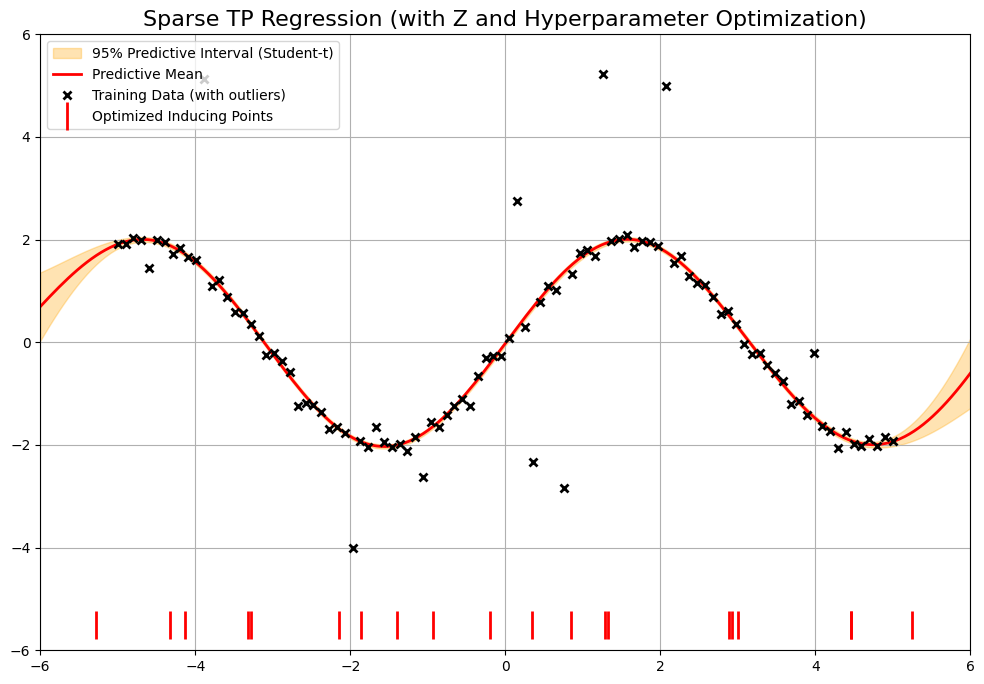

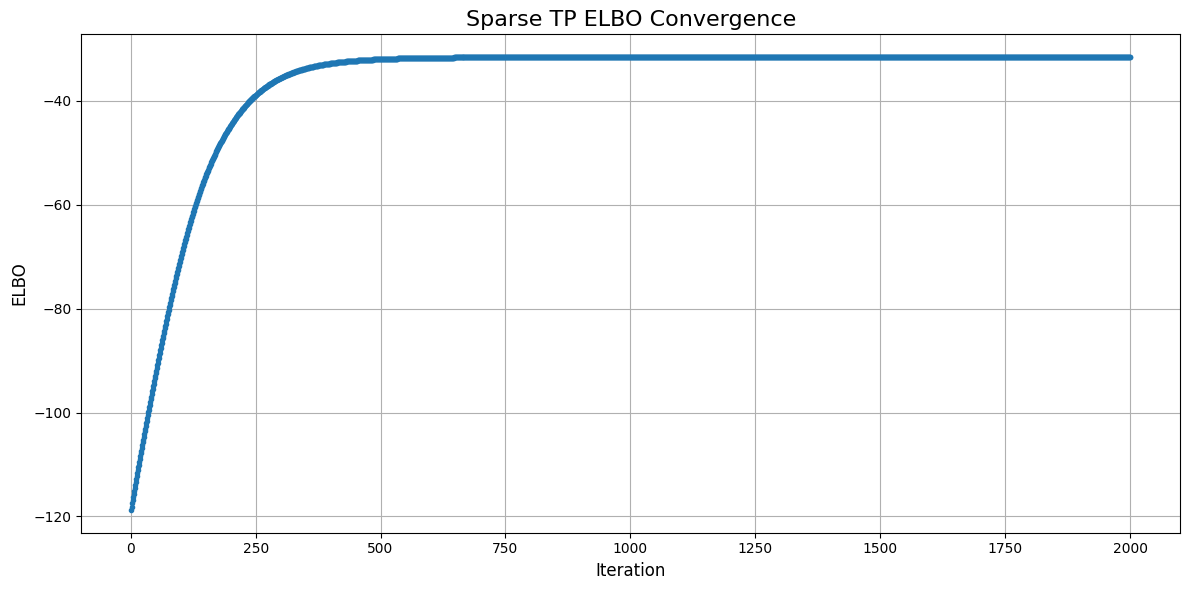

In [27]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.stats import t
import math

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    # Ensure lengthscale and variance are tensors for autograd
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class TPRegression:
    """
    Implementation of Variational EM for Student-t Process Regression.
    - E-Step: CAVI updates for variational parameters.
    - M-Step: Gradient-based optimization of model hyperparameters and inducing points.
    """
    def __init__(self, X, y, Z_initial, nu_f=5.0, nu_e=5.0, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0):
        self.X = X
        self.y = y.squeeze()
        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # --- Initialize Hyperparameters and Inducing Points (M-step) ---
        # These are now learnable parameters. We optimize their log for stability.
        self.log_nu_f = torch.nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_epsilon = torch.nn.Parameter(torch.log(torch.tensor(nu_e)))
        self.log_sigma_sq = torch.nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_kernel_lengthscale = torch.nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = torch.nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.Z = torch.nn.Parameter(Z_initial.clone())

        # --- Initialize Variational Parameters (E-step) ---
        self.m_u = torch.zeros(self.M, 1)
        self.S_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        self.alpha_lambda = torch.ones(self.N)
        self.beta_lambda = torch.ones(self.N)
        
    def _get_hyperparams(self):
        """Returns the exponentiated (positive) hyperparameters."""
        return {
            "nu_f": torch.exp(self.log_nu_f),
            "nu_epsilon": torch.exp(self.log_nu_epsilon),
            "sigma_sq": torch.exp(self.log_sigma_sq),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }
        
    def _e_step(self, cavi_max_iter=1):
        """Performs the CAVI updates for the variational parameters (E-Step)."""
        with torch.no_grad(): # No gradients needed for the E-step updates
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
            K_ZZ_inv = torch.inverse(K_ZZ)
            K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
            
            for _ in range(cavi_max_iter):
                # Update q(lambda)
                K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
                expected_f_mean = K_XZ @ K_ZZ_inv_m_u
                if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
                else: expected_r_inv = self.beta_r
                k_ii = torch.diag(rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']))
                K_XZ_K_ZZ_inv = K_XZ @ K_ZZ_inv
                var_f_term1 = expected_r_inv * (k_ii - (K_XZ_K_ZZ_inv * K_XZ).sum(dim=1))
                var_f_term2 = (K_XZ_K_ZZ_inv @ self.S_u * K_XZ_K_ZZ_inv).sum(dim=1)
                var_f = var_f_term1 + var_f_term2
                expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
                self.alpha_lambda = params['nu_epsilon'] / 2.0 + 0.5
                self.beta_lambda = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error

                # Update q(r)
                trace_term = torch.trace(K_ZZ_inv @ self.S_u)
                mean_term = self.m_u.T @ K_ZZ_inv @ self.m_u
                expected_u_quadratic_form = trace_term + mean_term
                self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
                self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

                # Update q(u)
                expected_r = self.alpha_r / self.beta_r
                expected_lambda = self.alpha_lambda / self.beta_lambda
                precision_u_prior = expected_r * K_ZZ_inv
                K_ZX = K_XZ.T
                A = K_ZX * (expected_lambda / params['sigma_sq'])
                B = A @ K_XZ
                precision_u_lik = K_ZZ_inv.T @ B @ K_ZZ_inv
                precision_u = precision_u_prior + precision_u_lik
                self.S_u = torch.inverse(precision_u + torch.eye(self.M) * 1e-6)
                b = K_ZZ_inv.T @ (K_ZX @ (expected_lambda * self.y / params['sigma_sq']))
                self.m_u = (self.S_u @ b).unsqueeze(1)

    def _calculate_elbo(self):
        """Calculates the Evidence Lower Bound (ELBO) for the M-step."""
        params = self._get_hyperparams()
        
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
        K_ZZ_inv = torch.inverse(K_ZZ)
        K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
        k_ii = torch.diag(rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']))

        # 1. Expected Log-Likelihood
        expected_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
        expected_lambda = self.alpha_lambda / self.beta_lambda
        K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
        expected_f_mean = K_XZ @ K_ZZ_inv_m_u
        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        K_XZ_K_ZZ_inv = K_XZ @ K_ZZ_inv
        var_f = expected_r_inv * (k_ii - (K_XZ_K_ZZ_inv * K_XZ).sum(dim=1)) + \
                (K_XZ_K_ZZ_inv @ self.S_u * K_XZ_K_ZZ_inv).sum(dim=1)
        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
        
        log_lik = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
                                  expected_lambda / params['sigma_sq'] * expected_sq_error)

        # 2. KL Divergences
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        kl_u = 0.5 * (
            -torch.logdet(self.S_u) - self.M * expected_log_r + torch.logdet(K_ZZ) + \
            (self.alpha_r / self.beta_r) * (torch.trace(K_ZZ_inv @ self.S_u) + self.m_u.T @ K_ZZ_inv @ self.m_u) - self.M
        ).squeeze()
        
        # CORRECTED a typo here: params['nu_e'] -> params['nu_epsilon']
        p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda = torch.sum((self.alpha_lambda - p_alpha_lambda) * torch.digamma(self.alpha_lambda) - \
                    torch.lgamma(self.alpha_lambda) + torch.lgamma(p_alpha_lambda) + \
                    p_alpha_lambda * (torch.log(self.beta_lambda) - torch.log(p_beta_lambda)) + \
                    self.alpha_lambda * (p_beta_lambda - self.beta_lambda) / self.beta_lambda)

        return log_lik - kl_u - kl_r - kl_lambda

    def _m_step(self, optimizer):
        """Performs the gradient update for the hyperparameters (M-Step)."""
        optimizer.zero_grad()
        elbo = self._calculate_elbo()
        loss = -elbo # Maximize ELBO by minimizing -ELBO
        loss.backward()
        optimizer.step()
        return elbo.item()

    def fit(self, max_iter_global=100, cavi_max_iter=10, lr=0.01):
        """Runs the full Variational EM algorithm."""
        optimizer = optim.Adam(
            [self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
             self.log_kernel_lengthscale, self.log_kernel_variance, self.Z],
            lr=lr
        )
        
        elbo_history = []
        print("Starting Variational EM optimization...")
        for i in range(max_iter_global):
            self._e_step(cavi_max_iter=cavi_max_iter)
            elbo = self._m_step(optimizer)
            elbo_history.append(elbo)
            
            if (i + 1) % 50 == 0:
                print(f"EM Iteration {i+1}/{max_iter_global}, ELBO: {elbo:.4f}")
        
        print("\nOptimization finished.")
        return elbo_history

    def predict(self, X_test):
        """
        Makes predictions for new data X_test.
        Returns the parameters of the predictive Student-t distribution.
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
            K_ZZ_inv = torch.inverse(K_ZZ)
            K_star_Z = rbf_kernel(X_test, self.Z, params['lengthscale'], params['variance'])
            k_star_star = torch.diag(rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']))

            K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
            pred_mean = (K_star_Z @ K_ZZ_inv_m_u).squeeze()

            K_star_Z_K_ZZ_inv = K_star_Z @ K_ZZ_inv
            gp_var = k_star_star - (K_star_Z_K_ZZ_inv * K_star_Z).sum(dim=1) + \
                     (K_star_Z_K_ZZ_inv @ self.S_u * K_star_Z_K_ZZ_inv).sum(dim=1)
            
            pred_nu = 2 * self.alpha_r
            pred_scale_sq = gp_var * (self.beta_r / self.alpha_r)
            
            return pred_mean, pred_scale_sq, pred_nu

if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model with INITIAL inducing points
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model and get ELBO history
    elbo_history = model.fit(max_iter_global=2000, cavi_max_iter=5, lr=0.01)

    # Print final Z locations
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')

    plt.title('Sparse TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='.', linestyle='-')
    plt.title('Sparse TP ELBO Convergence', fontsize=16)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()
